# Track Typhoon Vortex Centers From `wrfout_d01_*`

This notebook scans all `wrfout_d01_*` files in this folder, finds the vortex center as the minimum pressure point in each file, writes `time,latitude,longitude` to a CSV file, and plots the resulting track as a bold red line over the pressure field from the first file.

The code uses the local helper modules in this folder: `modPlotWRF.py`, `modDiagnoseWRF.py`, and `modColorCode.py`.

In [1]:
from pathlib import Path
import csv
import re
from datetime import datetime

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from mpl_toolkits.basemap import Basemap

import modColorCode as color
import modDiagnoseWRF as diag
import modPlotWRF as wrfplot

## Settings

In [8]:
data_dir = "."
file_pattern = "wrfout_d01_*"

# Time is parsed from filenames like wrfout_d01_2024-09-06_12:00:00.
filename_time_regex = r"(\d{4}-\d{2}-\d{2}_\d{2}:\d{2}:\d{2})"
filename_time_format = "%Y-%m-%d_%H:%M:%S"
output_time_format = "%Y-%m-%d_%H:%M:%S"

# WRF files usually contain one time per file. Change this if yours contain several.
time_index_in_each_file = 0

# Tracking criteria.
target_pressure_hpa = 850.0
center_agreement_km = 100.0
pressure_var_candidates = ("SLP", "slp", "PMSL", "MSLP", "PSFC")
landmask_var_candidates = ("LANDMASK", "XLAND")

track_output_file = "typhoon_track_d01.csv"
diagnostics_output_file = "typhoon_track_d01_diagnostics.csv"
figure_output_file = "typhoon_track_d01.png"
save_figure = True

# Optional plotting controls.
pressure_clevs = None  # Example: np.arange(940, 1021, 4). Leave as None for automatic levels.
pressure_auto_percentiles = (1, 99)
pressure_auto_level_count = 24
pressure_min_color = (0.95, 0.95, 1.0)
pressure_max_color = (0.0, 0.15, 0.75)
track_linewidth = 4.0
marker_size = 38
map_resolution = "l"

# Observed JTWC/ATCF best-track data for Typhoon Yagi.
observed_track_file = "bwp122024.dat"
plot_observed_track = True
observed_track_color = "black"
observed_track_marker_face = "yellow"
observed_track_linewidth = 2.6
observed_track_marker_size = 34

# 10-m wind vector overlay from the first WRF file.
plot_10m_wind_vectors = True
wind_vector_skip = 14
wind_vector_scale = 700
wind_vector_width = 0.0022
wind_vector_alpha = 0.75
wind_vector_key = 20



## Find and sort the WRF files

In [3]:
def parse_filename_time(path):
    match = re.search(filename_time_regex, path.name)
    if not match:
        return None, path.name

    time_text = match.group(1)
    try:
        parsed = datetime.strptime(time_text, filename_time_format)
    except ValueError:
        return None, time_text
    return parsed, time_text


def file_sort_key(path):
    parsed, time_text = parse_filename_time(path)
    if parsed is not None:
        return (0, parsed, path.name)
    return (1, time_text, path.name)


def output_time_from_filename(path):
    parsed, time_text = parse_filename_time(path)
    if parsed is not None:
        return parsed.strftime(output_time_format)
    return time_text


wrf_files = sorted(
    [p for p in Path(data_dir).glob(file_pattern) if p.is_file() and re.search(filename_time_regex, p.name)],
    key=file_sort_key,
)
if not wrf_files:
    raise FileNotFoundError(f"No files matched {file_pattern!r} in {Path(data_dir).resolve()}")

print(f"Found {len(wrf_files)} files:")
for path in wrf_files:
    print(f"  {path.name} -> {output_time_from_filename(path)}")

Found 41 files:
  wrfout_d01_2024-09-02_00:00:00 -> 2024-09-02_00:00:00
  wrfout_d01_2024-09-02_03:00:00 -> 2024-09-02_03:00:00
  wrfout_d01_2024-09-02_06:00:00 -> 2024-09-02_06:00:00
  wrfout_d01_2024-09-02_09:00:00 -> 2024-09-02_09:00:00
  wrfout_d01_2024-09-02_12:00:00 -> 2024-09-02_12:00:00
  wrfout_d01_2024-09-02_15:00:00 -> 2024-09-02_15:00:00
  wrfout_d01_2024-09-02_18:00:00 -> 2024-09-02_18:00:00
  wrfout_d01_2024-09-02_21:00:00 -> 2024-09-02_21:00:00
  wrfout_d01_2024-09-03_00:00:00 -> 2024-09-03_00:00:00
  wrfout_d01_2024-09-03_03:00:00 -> 2024-09-03_03:00:00
  wrfout_d01_2024-09-03_06:00:00 -> 2024-09-03_06:00:00
  wrfout_d01_2024-09-03_09:00:00 -> 2024-09-03_09:00:00
  wrfout_d01_2024-09-03_12:00:00 -> 2024-09-03_12:00:00
  wrfout_d01_2024-09-03_15:00:00 -> 2024-09-03_15:00:00
  wrfout_d01_2024-09-03_18:00:00 -> 2024-09-03_18:00:00
  wrfout_d01_2024-09-03_21:00:00 -> 2024-09-03_21:00:00
  wrfout_d01_2024-09-04_00:00:00 -> 2024-09-04_00:00:00
  wrfout_d01_2024-09-04_03:00:00

## Helper functions for the three-center tracking rule


In [4]:
def choose_pressure_variable(dataset):
    for name in pressure_var_candidates:
        if name in dataset:
            return name
    available = ", ".join(list(dataset.data_vars)[:30])
    raise KeyError(
        "No pressure variable was found. Tried "
        f"{pressure_var_candidates}. First available variables: {available}"
    )


def select_time_if_present(data_array, time_index=time_index_in_each_file):
    for dim in ("Time", "time", "times", "valid_time"):
        if dim in data_array.dims:
            return data_array.isel({dim: time_index})
    return data_array


def pressure_plane(dataset, pressure_name):
    pressure = select_time_if_present(dataset[pressure_name]).squeeze(drop=True)
    if pressure.ndim != 2:
        raise ValueError(f"Expected a 2D pressure field after time selection; got dims {pressure.dims}")
    return pressure.values


def lat_lon_arrays(dataset):
    if "XLAT" not in dataset or "XLONG" not in dataset:
        raise KeyError("This notebook expects WRF XLAT and XLONG variables for center latitude/longitude.")

    lat = select_time_if_present(dataset["XLAT"]).squeeze(drop=True)
    lon = select_time_if_present(dataset["XLONG"]).squeeze(drop=True)
    if lat.ndim != 2 or lon.ndim != 2:
        raise ValueError(f"Expected 2D XLAT/XLONG after time selection; got {lat.dims} and {lon.dims}")
    return lat.values, lon.values


def land_ocean_masks(dataset):
    mask_name = None
    for name in landmask_var_candidates:
        if name in dataset:
            mask_name = name
            break
    if mask_name is None:
        raise KeyError(f"No land mask variable was found. Tried {landmask_var_candidates}.")

    raw = select_time_if_present(dataset[mask_name]).squeeze(drop=True).values.astype(float)
    if raw.ndim != 2:
        raise ValueError(f"Expected a 2D land mask after time selection; got shape {raw.shape}")

    if mask_name.upper() == "XLAND":
        # WRF XLAND is usually 1 over land and 2 over water.
        land = np.isfinite(raw) & (raw < 1.5)
        ocean = np.isfinite(raw) & (raw >= 1.5)
    else:
        # WRF LANDMASK is usually 1 over land and 0 over water.
        land = np.isfinite(raw) & (raw >= 0.5)
        ocean = np.isfinite(raw) & (raw < 0.5)
    return land, ocean, mask_name


def pressure_for_display(values, pressure_name):
    display = np.asarray(values, dtype=float)
    units = "hPa"

    # WRF PSFC is usually in Pa. SLP-like fields may be Pa or hPa depending on preprocessing.
    if np.nanmedian(np.abs(display)) > 2000:
        display = display / 100.0

    if pressure_name.upper() == "PSFC":
        label_name = "Surface pressure (PSFC fallback)"
    else:
        label_name = f"Sea-level pressure ({pressure_name})"
    return display, f"{label_name} [{units}]"


def transpose_with_vertical_first(data_array, vertical_names):
    vertical_dim = next((dim for dim in data_array.dims if dim in vertical_names), None)
    if vertical_dim is None:
        raise ValueError(f"Could not find one of {vertical_names} in dims {data_array.dims}")
    horizontal_dims = [dim for dim in data_array.dims if dim != vertical_dim]
    if len(horizontal_dims) != 2:
        raise ValueError(f"Expected two horizontal dimensions in {data_array.dims}")
    return data_array.transpose(vertical_dim, *horizontal_dims)


def interpolate_to_pressure_level(pressure_pa, field, target_pa):
    pressure = np.asarray(pressure_pa, dtype=float)
    values = np.asarray(field, dtype=float)
    if pressure.shape != values.shape:
        raise ValueError(f"Pressure and field shapes differ: {pressure.shape} vs {values.shape}")

    # Work with pressure decreasing upward, which is the usual WRF mass-level order.
    if np.nanmean(pressure[0]) < np.nanmean(pressure[-1]):
        pressure = pressure[::-1]
        values = values[::-1]

    crosses = (pressure[:-1] >= target_pa) & (pressure[1:] <= target_pa)
    has_crossing = crosses.any(axis=0)
    k = np.argmax(crosses, axis=0)
    yy, xx = np.indices(has_crossing.shape)

    p1 = pressure[k, yy, xx]
    p2 = pressure[k + 1, yy, xx]
    v1 = values[k, yy, xx]
    v2 = values[k + 1, yy, xx]

    out = np.full(has_crossing.shape, np.nan, dtype=float)
    denom = p2 - p1
    ok = has_crossing & np.isfinite(p1) & np.isfinite(p2) & np.isfinite(v1) & np.isfinite(v2) & (denom != 0)
    weight = (target_pa - p1[ok]) / denom[ok]
    out[ok] = v1[ok] + weight * (v2[ok] - v1[ok])
    return out


def geopotential_height_at_pressure(dataset, target_hpa=target_pressure_hpa):
    required = ("P", "PB", "PHB")
    missing = [name for name in required if name not in dataset]
    if missing:
        raise KeyError(f"Cannot compute {target_hpa:g}-hPa geopotential height from PHB; missing {missing}")

    p_da = transpose_with_vertical_first(select_time_if_present(dataset["P"]).squeeze(drop=True), ("bottom_top", "level", "lev"))
    pb_da = transpose_with_vertical_first(select_time_if_present(dataset["PB"]).squeeze(drop=True), ("bottom_top", "level", "lev"))
    phb_da = transpose_with_vertical_first(select_time_if_present(dataset["PHB"]).squeeze(drop=True), ("bottom_top_stag", "level_stag", "lev_stag"))

    pressure_pa = p_da.values + pb_da.values
    # Use PHB only, as requested. PHB is staggered vertically, so average adjacent
    # staggered levels to the WRF mass levels before interpolating to 850 hPa.
    height_mass = 0.5 * (phb_da.values[:-1] + phb_da.values[1:]) / 9.80665

    return interpolate_to_pressure_level(pressure_pa, height_mass, target_hpa * 100.0)


def wind10m_speed(dataset):
    if "U10" not in dataset or "V10" not in dataset:
        raise KeyError("Maximum 10-m wind criterion requires U10 and V10 variables.")
    u10 = select_time_if_present(dataset["U10"]).squeeze(drop=True).values
    v10 = select_time_if_present(dataset["V10"]).squeeze(drop=True).values
    return np.sqrt(np.square(u10) + np.square(v10))



def parse_atcf_coordinate(text):
    text = text.strip().upper()
    if not text:
        return np.nan
    hemisphere = text[-1]
    value = float(text[:-1]) / 10.0
    if hemisphere in ("S", "W"):
        value = -value
    return value


def parse_observed_track(path):
    path = Path(path)
    if not path.exists():
        print(f"Observed track file was not found: {path.resolve()}")
        return []

    observed_rows = []
    with path.open() as f:
        for line in f:
            if not line.strip():
                continue
            parts = [part.strip() for part in line.split(",")]
            if len(parts) < 8:
                continue
            if len(parts) > 4 and parts[4].upper() != "BEST":
                continue

            try:
                valid_time = datetime.strptime(parts[2], "%Y%m%d%H")
                latitude = parse_atcf_coordinate(parts[6])
                longitude = parse_atcf_coordinate(parts[7])
            except (ValueError, IndexError):
                continue

            if not np.isfinite(latitude) or not np.isfinite(longitude):
                continue

            observed_rows.append({
                "time": valid_time.strftime(output_time_format),
                "datetime": valid_time,
                "latitude": latitude,
                "longitude": longitude,
                "vmax_kt": float(parts[8]) if len(parts) > 8 and parts[8] else np.nan,
                "pressure_hpa": float(parts[9]) if len(parts) > 9 and parts[9] else np.nan,
            })

    observed_rows.sort(key=lambda row: row["datetime"])
    return observed_rows


def center_dict(row, col, lats, lons, field, method, units):
    return {
        "method": method,
        "row": int(row),
        "col": int(col),
        "latitude": float(lats[row, col]),
        "longitude": float(lons[row, col]),
        "value": float(field[row, col]),
        "units": units,
    }


def masked_min_center(field, valid_mask, lats, lons, method, units):
    valid = valid_mask & np.isfinite(field)
    if not valid.any():
        raise ValueError(f"No valid points for {method}")
    search = np.where(valid, field, np.inf)

    # Use the local WRF helper function for the minimum-location search.
    row, col = wrfplot.min_pressure_center_index(search)
    return center_dict(row, col, lats, lons, field, method, units)


def masked_max_center(field, valid_mask, lats, lons, method, units):
    valid = valid_mask & np.isfinite(field)
    if not valid.any():
        raise ValueError(f"No valid points for {method}")
    search = np.where(valid, field, -np.inf)
    row, col = np.unravel_index(np.nanargmax(search), search.shape)
    return center_dict(row, col, lats, lons, field, method, units)


def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0
    phi1, phi2 = np.radians([lat1, lat2])
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return float(2.0 * radius_km * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a)))


def pairwise_distances_km(centers):
    names = list(centers)
    distances = {}
    for i, name1 in enumerate(names):
        for name2 in names[i + 1:]:
            c1 = centers[name1]
            c2 = centers[name2]
            distances[f"{name1}_to_{name2}_km"] = haversine_km(
                c1["latitude"], c1["longitude"], c2["latitude"], c2["longitude"]
            )
    return distances


def find_vortex_center(path):
    errors = []
    with xr.open_dataset(path) as dataset:
        pressure_name = choose_pressure_variable(dataset)
        pressure = pressure_plane(dataset, pressure_name)
        lats, lons = lat_lon_arrays(dataset)
        land_mask, ocean_mask, landmask_name = land_ocean_masks(dataset)
        z850 = geopotential_height_at_pressure(dataset, target_pressure_hpa)
        speed10 = wind10m_speed(dataset)

        try:
            pressure_ocean = masked_min_center(
                pressure, ocean_mask, lats, lons,
                "minimum pressure over ocean", pressure_name,
            )
        except Exception as exc:
            pressure_ocean = None
            errors.append(f"pressure_ocean: {exc}")

        try:
            z850_land = masked_min_center(
                z850, land_mask, lats, lons,
                f"minimum {target_pressure_hpa:g}-hPa height over land", "m",
            )
        except Exception as exc:
            z850_land = None
            errors.append(f"z850_land: {exc}")

        try:
            wind10m = masked_max_center(
                speed10, np.ones_like(speed10, dtype=bool), lats, lons,
                "maximum 10-m wind", "m s-1",
            )
        except Exception as exc:
            wind10m = None
            errors.append(f"wind10m: {exc}")

        # Required fallback when the three criteria disagree by more than center_agreement_km.
        z850_ocean = masked_min_center(
            z850, ocean_mask, lats, lons,
            f"minimum {target_pressure_hpa:g}-hPa height over ocean", "m",
        )

        criteria = {
            "pressure_ocean": pressure_ocean,
            "z850_land": z850_land,
            "wind10m": wind10m,
        }
        complete_criteria = {name: center for name, center in criteria.items() if center is not None}

        if len(complete_criteria) == 3:
            distances = pairwise_distances_km(complete_criteria)
            max_distance = max(distances.values()) if distances else 0.0
            if max_distance <= center_agreement_km:
                final_center = pressure_ocean
                selection_rule = "criteria_agree_use_pressure_ocean"
            else:
                final_center = z850_ocean
                selection_rule = "fallback_z850_ocean_disagreement"
        else:
            distances = pairwise_distances_km(complete_criteria) if len(complete_criteria) > 1 else {}
            max_distance = max(distances.values()) if distances else np.nan
            final_center = z850_ocean
            selection_rule = "fallback_z850_ocean_missing_criterion"

        row = {
            "time": output_time_from_filename(path),
            "latitude": final_center["latitude"],
            "longitude": final_center["longitude"],
            "row": final_center["row"],
            "col": final_center["col"],
            "selected_method": final_center["method"],
            "selection_rule": selection_rule,
            "max_criteria_distance_km": max_distance,
            "pressure_name": pressure_name,
            "landmask_name": landmask_name,
            "file": path.name,
            "errors": "; ".join(errors),
        }

        for prefix, center in {
            "pressure_ocean": pressure_ocean,
            "z850_land": z850_land,
            "wind10m": wind10m,
            "z850_ocean_fallback": z850_ocean,
        }.items():
            if center is None:
                row.update({
                    f"{prefix}_lat": np.nan,
                    f"{prefix}_lon": np.nan,
                    f"{prefix}_row": np.nan,
                    f"{prefix}_col": np.nan,
                    f"{prefix}_value": np.nan,
                })
            else:
                row.update({
                    f"{prefix}_lat": center["latitude"],
                    f"{prefix}_lon": center["longitude"],
                    f"{prefix}_row": center["row"],
                    f"{prefix}_col": center["col"],
                    f"{prefix}_value": center["value"],
                })
        row.update(distances)
        return row

## Extract the consensus vortex track and write output files


In [5]:
track_rows = [find_vortex_center(path) for path in wrf_files]

output_path = Path(track_output_file)
with output_path.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["time", "latitude", "longitude"])
    for row in track_rows:
        writer.writerow([row["time"], f"{row['latitude']:.6f}", f"{row['longitude']:.6f}"])

# A separate diagnostics file keeps the main track file in the requested time/lat/lon order.
diagnostics_path = Path(diagnostics_output_file)
diagnostic_columns = [
    "time", "latitude", "longitude", "selection_rule", "selected_method", "max_criteria_distance_km",
    "pressure_ocean_lat", "pressure_ocean_lon", "pressure_ocean_value",
    "z850_land_lat", "z850_land_lon", "z850_land_value",
    "wind10m_lat", "wind10m_lon", "wind10m_value",
    "z850_ocean_fallback_lat", "z850_ocean_fallback_lon", "z850_ocean_fallback_value",
    "pressure_ocean_to_z850_land_km", "pressure_ocean_to_wind10m_km", "z850_land_to_wind10m_km",
    "pressure_name", "landmask_name", "file", "errors",
]
with diagnostics_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=diagnostic_columns, extrasaction="ignore")
    writer.writeheader()
    for row in track_rows:
        writer.writerow(row)

print(f"Wrote track file: {output_path.resolve()}")
print(f"Wrote diagnostics file: {diagnostics_path.resolve()}")

observed_track_rows = parse_observed_track(observed_track_file) if plot_observed_track else []
print(f"Read {len(observed_track_rows)} observed Yagi track points from {observed_track_file}.")
print("time, latitude, longitude, rule, max criteria distance km")
for row in track_rows:
    max_dist = row["max_criteria_distance_km"]
    max_dist_text = "nan" if not np.isfinite(max_dist) else f"{max_dist:.1f}"
    print(
        f"{row['time']}, {row['latitude']:.4f}, {row['longitude']:.4f}, "
        f"{row['selection_rule']}, {max_dist_text}"
    )

min index is (np.int64(494), np.int64(42))
min index is (np.int64(229), np.int64(336))
min index is (np.int64(231), np.int64(345))
min index is (np.int64(494), np.int64(42))
min index is (np.int64(231), np.int64(334))
min index is (np.int64(234), np.int64(341))
min index is (np.int64(494), np.int64(42))
min index is (np.int64(247), np.int64(336))
min index is (np.int64(241), np.int64(341))
min index is (np.int64(494), np.int64(42))
min index is (np.int64(247), np.int64(336))
min index is (np.int64(248), np.int64(341))
min index is (np.int64(494), np.int64(42))
min index is (np.int64(257), np.int64(340))
min index is (np.int64(256), np.int64(340))
min index is (np.int64(494), np.int64(42))
min index is (np.int64(267), np.int64(336))
min index is (np.int64(266), np.int64(337))
min index is (np.int64(494), np.int64(42))
min index is (np.int64(270), np.int64(330))
min index is (np.int64(273), np.int64(331))
min index is (np.int64(494), np.int64(42))
min index is (np.int64(276), np.int64(32

## Inspect the first file with local WRF helpers

In [6]:
first_file = wrf_files[0]
with xr.open_dataset(first_file) as ds0:
    print(f"Reference file: {first_file.name}")
    print("2D/time-varying variables from modPlotWRF.info2D:")
    wrfplot.info2D(ds0)

    # Use the lightweight class from modPlotWRF to keep grid dimensions together.
    pressure_name = choose_pressure_variable(ds0)
    pressure_raw = pressure_plane(ds0, pressure_name)
    lats, lons = lat_lon_arrays(ds0)
    ny, nx = pressure_raw.shape
    dx_raw = float(np.asarray(getattr(ds0, "DX", 1.0)).ravel()[0])
    dx_km = dx_raw / 1000.0 if dx_raw > 100.0 else dx_raw
    grid2d = wrfplot.var2D(nx=nx, ny=ny, dx=dx_km)

    if "U10" in ds0 and "V10" in ds0:
        u10_first = select_time_if_present(ds0["U10"]).squeeze(drop=True).values
        v10_first = select_time_if_present(ds0["V10"]).squeeze(drop=True).values
    else:
        u10_first = None
        v10_first = None
        print("U10/V10 were not found in the first WRF file; wind vectors will be skipped.")

print(f"Grid stored in modPlotWRF.var2D: nx={grid2d.nx}, ny={grid2d.ny}, dx={grid2d.dx:g} km")

Reference file: wrfout_d01_2024-09-02_00:00:00
2D/time-varying variables from modPlotWRF.info2D:
Variable: LU_INDEX, ('Time', 'south_north', 'west_east')
Variable: VAR_SSO, ('Time', 'south_north', 'west_east')
Variable: MU, ('Time', 'south_north', 'west_east')
Variable: MUB, ('Time', 'south_north', 'west_east')
Variable: NEST_POS, ('Time', 'south_north', 'west_east')
Variable: Q2, ('Time', 'south_north', 'west_east')
Variable: T2, ('Time', 'south_north', 'west_east')
Variable: TH2, ('Time', 'south_north', 'west_east')
Variable: PSFC, ('Time', 'south_north', 'west_east')
Variable: U10, ('Time', 'south_north', 'west_east')
Variable: V10, ('Time', 'south_north', 'west_east')
Variable: AREA2D, ('Time', 'south_north', 'west_east')
Variable: DX2D, ('Time', 'south_north', 'west_east')
Variable: SHDMAX, ('Time', 'south_north', 'west_east')
Variable: SHDMIN, ('Time', 'south_north', 'west_east')
Variable: SHDAVG, ('Time', 'south_north', 'west_east')
Variable: SNOALB, ('Time', 'south_north', 'wes

## Plot the track over the first file's pressure field

Saved figure: /geode3/home/u020/ckieu/BigRed200/model/diagnosePy/typhoon_track_d01.png


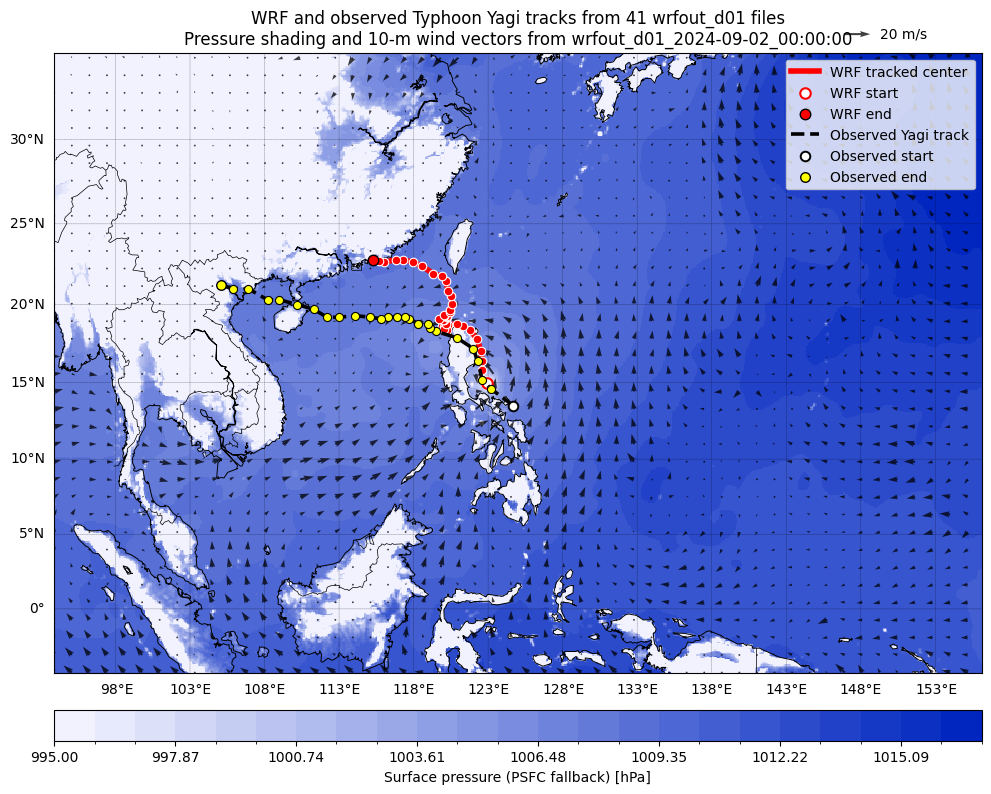

In [19]:
pressure_plot, pressure_label = pressure_for_display(pressure_raw, pressure_name)

if pressure_clevs is None:
    vmin, vmax = np.nanpercentile(pressure_plot, pressure_auto_percentiles)
    if np.isclose(vmin, vmax):
        vmin, vmax = float(np.nanmin(pressure_plot)), float(np.nanmax(pressure_plot))
    vmin, vmax = 995, 1017
    pressure_levels = np.linspace(vmin, vmax, pressure_auto_level_count)
else:
    pressure_levels = np.asarray(pressure_clevs, dtype=float)

pressure_cmap = ListedColormap(color.myColor(pressure_levels, pressure_min_color, pressure_max_color))
pressure_norm = BoundaryNorm(pressure_levels, pressure_cmap.N)

lat_min, lat_max = float(np.nanmin(lats)), float(np.nanmax(lats))
lon_min, lon_max = float(np.nanmin(lons)), float(np.nanmax(lons))
lat_pad = 0 # max(0.25, 0.03 * (lat_max - lat_min))
lon_pad = 0 # max(0.25, 0.03 * (lon_max - lon_min))

fig, ax = plt.subplots(figsize=(10, 8))
m = Basemap(
    projection="merc",
    llcrnrlat=lat_min - lat_pad,
    urcrnrlat=lat_max + lat_pad,
    llcrnrlon=lon_min - lon_pad,
    urcrnrlon=lon_max + lon_pad,
    resolution=map_resolution,
    ax=ax,
)

x, y = m(lons, lats)
shaded = m.pcolormesh(x, y, pressure_plot, cmap=pressure_cmap, norm=pressure_norm, shading="auto")
#shaded = m.pcolormesh(x, y, pressure_plot,cmap="coolwarm",norm=pressure_norm)
cbar = m.colorbar(shaded, location="bottom", pad="6%")
cbar.set_label(pressure_label)

if plot_10m_wind_vectors and u10_first is not None and v10_first is not None:
    skip = max(1, int(wind_vector_skip))
    vector_slice = (slice(None, None, skip), slice(None, None, skip))
    q = m.quiver(
        x[vector_slice],
        y[vector_slice],
        u10_first[vector_slice],
        v10_first[vector_slice],
        scale=wind_vector_scale,
        width=wind_vector_width,
        color="black",
        alpha=wind_vector_alpha,
        zorder=4,
    )
    ax.quiverkey(
        q,
        0.88,
        1.03,
        wind_vector_key,
        f"{wind_vector_key:g} m/s",
        labelpos="E",
        coordinates="axes",
    )

m.drawcoastlines(linewidth=0.7)
m.drawcountries(linewidth=0.5)
m.drawparallels(np.arange(np.floor(lat_min), np.ceil(lat_max) + 1, 5), labels=[1, 0, 0, 0], linewidth=0.25)
m.drawmeridians(np.arange(np.floor(lon_min), np.ceil(lon_max) + 1, 5), labels=[0, 0, 0, 1], linewidth=0.25)

track_lats = np.array([row["latitude"] for row in track_rows[:-3]])
track_lons = np.array([row["longitude"] for row in track_rows[:-3]])
tx, ty = m(track_lons, track_lats)

m.plot(tx, ty, color="red", linewidth=track_linewidth, zorder=6, label="WRF tracked center")
m.scatter(tx, ty, s=marker_size, color="red", edgecolor="white", linewidth=0.8, zorder=7)
m.scatter(tx[0], ty[0], s=marker_size * 1.5, color="white", edgecolor="red", linewidth=1.5, zorder=8, label="WRF start")
m.scatter(tx[-1], ty[-1], s=marker_size * 1.5, color="red", edgecolor="black", linewidth=1.0, zorder=8, label="WRF end")

if plot_observed_track:
    if "observed_track_rows" not in globals():
        observed_track_rows = parse_observed_track(observed_track_file)
    if observed_track_rows:
        obs_lats = np.array([row["latitude"] for row in observed_track_rows])
        obs_lons = np.array([row["longitude"] for row in observed_track_rows])
        ox, oy = m(obs_lons, obs_lats)
        m.plot(
            ox,
            oy,
            color=observed_track_color,
            linewidth=observed_track_linewidth,
            linestyle="--",
            zorder=9,
            label="Observed Yagi track",
        )
        m.scatter(
            ox,
            oy,
            s=observed_track_marker_size,
            facecolor=observed_track_marker_face,
            edgecolor=observed_track_color,
            linewidth=0.8,
            zorder=10,
        )
        m.scatter(
            ox[0],
            oy[0],
            s=observed_track_marker_size * 1.4,
            facecolor="white",
            edgecolor=observed_track_color,
            linewidth=1.4,
            zorder=11,
            label="Observed start",
        )
        m.scatter(
            ox[-1],
            oy[-1],
            s=observed_track_marker_size * 1.4,
            facecolor=observed_track_marker_face,
            edgecolor="black",
            linewidth=1.0,
            zorder=11,
            label="Observed end",
        )
    else:
        print("No observed track points were available for plotting.")

ax.set_title(
    f"WRF and observed Typhoon Yagi tracks from {len(track_rows)} wrfout_d01 files\n"
    f"Pressure shading and 10-m wind vectors from {first_file.name}"
)
ax.legend(loc="upper right")
plt.tight_layout()

if save_figure:
    plt.savefig(figure_output_file, dpi=150, bbox_inches="tight")
    print(f"Saved figure: {Path(figure_output_file).resolve()}")

plt.show()